Proyecto de Análisis de Datos: Shark Attacks

Actividades acuáticas más frecuentemente asociadas a ataques de tiburón

## 1. Enfoque

El objetivo de este proyecto es analizar qué actividades acuáticas aparecen con mayor frecuencia asociadas a ataques de tiburón registrados en el dataset.

A través de un proceso de limpieza, transformación y análisis exploratorio de datos (EDA), buscamos identificar patrones que permitan entender qué prácticas acuáticas aparecen más frecuentemente en este tipo de incidentes.

Este análisis pretende aportar una visión basada en datos que ayude a comprender mejor los contextos en los que se registran ataques de tiburón.

**Nota importante:** este análisis identifica actividades más frecuentemente asociadas a ataques registrados, pero no representa el riesgo real absoluto para cada practicante.

!pip install xlrd #

## 3. Carga del dataset

In [8]:
import pandas as pd
df = pd.read_excel("GSAF5.xls", engine="xlrd")
print(df.head())

              Date    Year        Type    Country             State  \
0            14/04  2026.0  UNprovoked   Maldives  Gaafu Alif Atoll   
1        3rd April  2026.0  Unprovoked  Australia   South Australia   
2       26th March  2026.0  Unprovoked    Bahamas     Andros Island   
3       25th March  2026.0  Unprovoked  Australia   South Australia   
4  22nd-23rd March  2026.0  Unprovoked  Australia               NSW   

                                      Location  Activity  \
0                                      Kooddoo  Swimming   
1  Middleton Beach Fleurieu Peninsula Adelaide   Surfing   
2                                  Fresh Creek  Swimming   
3                   Cape Jaffa Limestone Coast    Diving   
4                          Little Avalon Beach   Surfing   

                        Name Sex  Age  ...                         Species   \
0  Not stated - on honeymoon   M    ?  ...                          Unknown   
1       Oliver Tokic-Bensley   M   16  ...            

In [ ]:
df.head() #ver el dataframe

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,14/04,2026.0,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,?,...,Unknown,The U.S. Sun: Simon De Marchi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3rd April,2026.0,Unprovoked,Australia,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,Oliver Tokic-Bensley,M,16,...,Bronze Whaler,ABC News: The Guardian: Andrew Currie and Bob...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26th March,2026.0,Unprovoked,Bahamas,Andros Island,Fresh Creek,Swimming,Australian woman,F,22,...,Unknown,WIC News: Melissa Michaelson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25th March,2026.0,Unprovoked,Australia,South Australia,Cape Jaffa Limestone Coast,Diving,Luke Kuhn,M,?,...,Great White Shark 3.5m (11.5ft),Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd-23rd March,2026.0,Unprovoked,Australia,NSW,Little Avalon Beach,Surfing,Unknown,M,30+,...,Unknown,Melissa Michaelson: Instagram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Estamos viendo las primeras filas del dataset, columnas disponibles y el formato general de los datos

## 4. Exploración inicial del dataset

Antes del proceso de limpieza, entenderemos la estructura del dataset: número de filas, columnas disponibles, tipos de datos y presencia de valores nulos.

In [ ]:
df.shape # Tamaño del dataset para ver número de filas número de columnas

(7087, 23)

In [ ]:
df.columns # Nombre de las columnas

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')

In [ ]:
df.info() # Importante para ver tipos de datos, cantidad de valores no nulos, columnas con posibles problemas

<class 'pandas.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7087 non-null   object 
 1   Year            7085 non-null   float64
 2   Type            7069 non-null   str    
 3   Country         7037 non-null   str    
 4   State           6600 non-null   str    
 5   Location        6520 non-null   str    
 6   Activity        6504 non-null   str    
 7   Name            6869 non-null   str    
 8   Sex             6509 non-null   str    
 9   Age             4093 non-null   object 
 10  Injury          7051 non-null   str    
 11  Fatal Y/N       6526 non-null   object 
 12  Time            3560 non-null   object 
 13  Species         3956 non-null   str    
 14  Source          7067 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   str    
 17  href            6796 non-null   str    
 18 

In [ ]:
df.isna().sum() # Columnas con valores nulos.

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                288
href formula       293
href               291
Case Number        289
Case Number.1      290
original order     288
Unnamed: 21       7086
Unnamed: 22       7085
dtype: int64

In [ ]:
df.duplicated().sum() # Esto muestra cuántas filas duplicadas hay en el dataset.

np.int64(0)

## 5. Selección de columnas relevantes

Dado que el objetivo del proyecto es analizar las actividades asociadas a ataques de tiburón, no es necesario utilizar todas las columnas del dataset.

Seleccionaremos únicamente aquellas que aportan valor para nuestro análisis.

In [ ]:
df = df[["Activity","Country","Year","Sex","Age","Fatal Y/N"]] # decido usar estas columnas

In [ ]:
df.head() # Ahora el dataset quedó más pequeño y enfocado en el análisis.

,Activity,Country,Year,Sex,Age,Fatal Y/N
0,Swimming,Maldives,2026.0,M,?,N
1,Surfing,Australia,2026.0,M,16,N
2,Swimming,Bahamas,2026.0,F,22,N
3,Diving,Australia,2026.0,M,?,N
4,Surfing,Australia,2026.0,M,30+,N


## 6. Limpieza de datos

En esta etapa realizamos las primeras tareas de limpieza:

- eliminación de duplicados
- revisión de valores nulos
- normalización de texto

In [10]:
df = df.drop_duplicates() # Eliminamos duplicados

In [12]:
df.duplicated().sum() # Comprobamos que se hayan eliminado da 0

np.int64(0)

In [13]:
df.isna().sum() # Revisamos nuevamente los valores nulos para comprobar

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                288
href formula       293
href               291
Case Number        289
Case Number.1      290
original order     288
Unnamed: 21       7086
Unnamed: 22       7085
dtype: int64

In [14]:
df = df.dropna(subset=["Activity"]) # Eliminamos filas sin información de la columna Activity.


In [15]:
df["Activity"] = df["Activity"].str.lower().str.strip() # Normalizamos el texto de la columna Activity.

In [16]:
df["Fatal Y/N"] = df["Fatal Y/N"].str.strip().str.upper() # Limpiamos formato de la columna Fatal.

In [17]:
df["Activity"].value_counts().head(20) # Aqui vemos las actividades más frecuentes en el dataset.

Activity
surfing            1156
swimming           1063
fishing             510
spearfishing        399
wading              178
bathing             167
diving              154
snorkeling          136
standing            115
scuba diving        106
body boarding        70
boogie boarding      60
body surfing         55
kayaking             43
free diving          35
treading water       33
fell overboard       33
pearl diving         32
surf skiing          24
windsurfing          20
Name: count, dtype: int64

## 7. Análisis exploratorio de datos (EDA)

A continuación analizaremos la distribución de ataques según la actividad registrada.

Como podemos ver esto muestra las 10 actividades con más ataques registrados:

In [18]:
activity_counts = df.groupby("Activity").size().sort_values(ascending=False)
activity_counts.head(10)

Activity
surfing         1156
swimming        1063
fishing          510
spearfishing     399
wading           178
bathing          167
diving           154
snorkeling       136
standing         115
scuba diving     106
dtype: int64

## 8. Visualización de actividades con más ataques

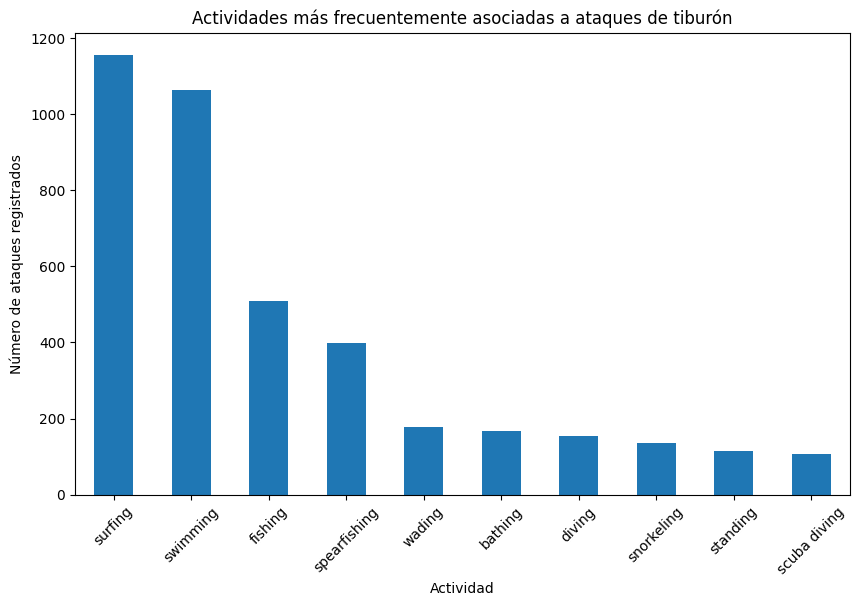

In [19]:
activity_counts.head(10).plot(kind="bar", figsize=(10,6))
plt.title("Actividades más frecuentemente asociadas a ataques de tiburón")
plt.xlabel("Actividad")
plt.ylabel("Número de ataques registrados")
plt.xticks(rotation=45)
plt.show()

## 9. Análisis complementario: Actividad vs fatalidad

Además de analizar la frecuencia de actividades, exploramos la relación entre la actividad realizada y si el ataque fue fatal o no fatal.

In [21]:
activity_fatality = df.groupby(["Activity","Fatal Y/N"]).size().reset_index(name="cantidad")
activity_fatality.head(20)

,Activity,Fatal Y/N,cantidad
0,,N,2
1,"""boat accident""",Y,1
2,"""climbing up to ship after repairing the stern...",Y,1
3,"""crossing the river""",Y,1
4,"""flying tiger"" transport plane went down with ...",N,1
5,"""flying tiger"" transport plane went down with ...",Y,1
6,"""riding waves on a board""",N,1
7,"""swimming vigorously""",N,1
8,.,Y,1
9,13 men in the water after sailboat capsized & ...,Y,1


In [22]:
top_activities = activity_counts.head(10).index
activity_fatality_top = activity_fatality[activity_fatality["Activity"].isin(top_activities)]

In [23]:
tabla_fatal = activity_fatality_top.pivot(index="Activity", columns="Fatal Y/N", values="cantidad").fillna(0)
tabla_fatal

Fatal Y/N,F,M,N,NQ,UNKNOWN,Y
Activity,,,,,,
bathing,0.0,0.0,79.0,0.0,2.0,71.0
diving,0.0,0.0,108.0,0.0,5.0,26.0
fishing,0.0,1.0,432.0,0.0,3.0,52.0
scuba diving,0.0,0.0,66.0,0.0,0.0,18.0
snorkeling,0.0,0.0,110.0,0.0,0.0,20.0
spearfishing,1.0,1.0,314.0,0.0,3.0,55.0
standing,0.0,0.0,98.0,0.0,0.0,16.0
surfing,1.0,0.0,1043.0,1.0,6.0,65.0
swimming,1.0,0.0,609.0,0.0,7.0,348.0


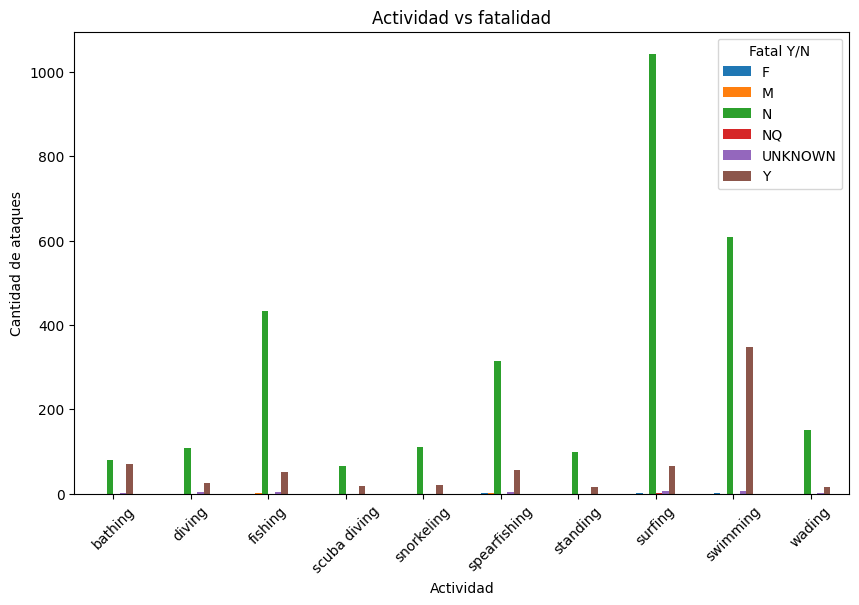

In [24]:
tabla_fatal.plot(kind="bar", figsize=(10,6))
plt.title("Actividad vs fatalidad")
plt.xlabel("Actividad")
plt.ylabel("Cantidad de ataques")
plt.xticks(rotation=45)
plt.show()

## 10. Insights principales

A partir del análisis exploratorio podemos observar:

- Algunas actividades acuáticas aparecen con mayor frecuencia en los registros de ataques de tiburón.
- Actividades como el surf, la natación o la pesca aparecen repetidamente en el dataset.
- Al analizar la relación entre actividad y fatalidad, observamos que la mayoría de ataques registrados no resultan fatales.

## 11. Conclusión

El análisis permitió identificar qué actividades aparecen con mayor frecuencia asociadas a ataques de tiburón registrados.

El proyecto incluyó:

- exploración inicial del dataset
- limpieza de datos
- tratamiento de valores nulos
- uso de técnicas de agregación con groupby
- visualización de resultados

Los resultados muestran que ciertas actividades acuáticas aparecen con mayor frecuencia en los registros de ataques.

Sin embargo, es importante destacar que este análisis refleja únicamente la frecuencia dentro del dataset y no el riesgo real absoluto de cada actividad.